# Van der pol Oscilator - Distributed Observer

In [6]:
import control as ct
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp

In [7]:
x1_dot_i = lambda eps, x1, x2, x1bar: x2 + eps*(x1bar - x1)
x2_dot_i = lambda eps, b, x1, x2, x2bar: b*(1 - x1**2)*x2 - x1 - eps*(x2bar - x2)

In [42]:
def model(t: float, x: np.ndarray[float], nOscilators: int, eps_list: list[list[float]], b: float):
    n = 2
    xdot = np.zeros(shape=x.shape)

    for i in range(0, nOscilators):
        index = i*2

        x1 = x[index]
        x2 = x[index+1]

        # coupli
        x1bar = np.sum(x[index::n])/nOscilators
        x2bar = np.sum(x[index+1::n])/nOscilators

        xdot[index]   = x1_dot_i(eps_list[i][0], x1, x2, x1bar)
        xdot[index+1] = x2_dot_i(eps_list[i][1], b, x1, x2, x2bar)
    
    return xdot.flatten()

In [86]:
sim_time = (0, 5)
x0 = np.array([1, 0, 1, 0])

b = 2.5 # damping coeficient

# [[
#   strength attractive coupling,
#   strength repulsive coupling
# ]]
eps_list = [
    [0.1, 0.1],
    [0.1, 0.1]
]

result = solve_ivp(model, sim_time, x0, args=(2, eps_list, b))
t = result.t
x = result.y

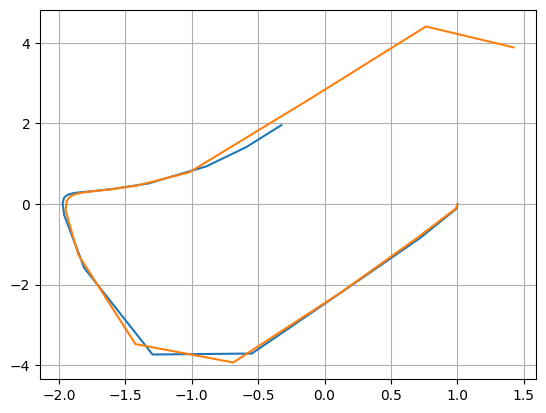

: 

In [ ]:
plt.figure()
plt.plot(x[0, :], x[1, :])
plt.plot(x[2, :], x[3, :])
plt.grid()
plt.show()